# Curve fitting with pounce

`pounce.curve_fit` is a [`scipy.optimize.curve_fit`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html)-style
front end that fits a model `f(x, *params)` to data — but because pounce is a
constrained interior-point solver that keeps its converged factorization, the
result carries a lot more:

- parameter **covariance, standard errors, and confidence intervals** (read from
  the solver's *reduced Hessian*),
- **robust losses** (Huber, Cauchy, soft-L1) that resist outliers,
- **parameter constraints** — positivity, ranges, and relations between
  parameters — that scipy's `curve_fit` cannot express, and
- **data sensitivity** `∂params/∂data` from a single back-solve.

Write the model with `jax.numpy` and pounce differentiates it exactly (no finite
differences), which is what makes the covariance and sensitivity sharp.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
import pounce
print("pounce", pounce.__version__)

pounce 0.9.0


## A model and some data

We fit an **exponential decay to an offset**, $f(x) = a\,e^{-bx} + c$, with
heteroscedastic (input-dependent) noise. The model is written with `jax.numpy`
so pounce can autodiff it.

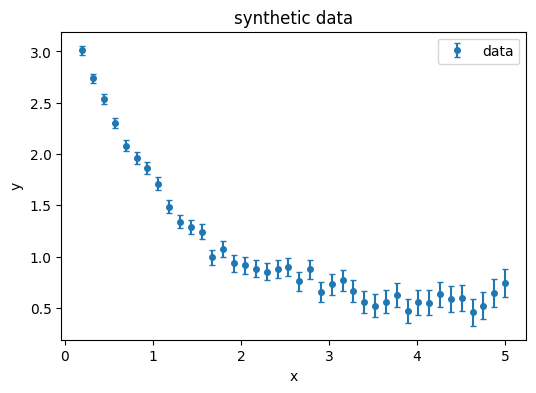

In [2]:
def model(x, a, b, c):
    return a * jnp.exp(-b * x) + c

def model_np(x, a, b, c):       # plain-numpy twin, for generating data
    return a * np.exp(-b * x) + c

rng = np.random.default_rng(0)
x = np.linspace(0.2, 5.0, 40)
a_true, b_true, c_true = 3.0, 0.9, 0.5
sigma = 0.04 + 0.02 * x                      # noise grows with x
y = model_np(x, a_true, b_true, c_true) + rng.normal(0.0, sigma)

plt.figure(figsize=(6, 4))
plt.errorbar(x, y, yerr=sigma, fmt='o', ms=4, capsize=2, label='data')
plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.title('synthetic data');

## A basic weighted fit

Pass `sigma` for a weighted ($\chi^2$) fit, exactly like scipy. The result's
`summary()` reports the parameters, standard errors, confidence intervals, and
goodness-of-fit in one place.

In [3]:
res = pounce.curve_fit(model, x, y, p0=[1, 1, 0], sigma=sigma)
print(res.summary())
print('\ntruth      = [3.0, 0.9, 0.5]')
print('covariance from:', res.cov_source)

curve_fit summary  (loss=sse, cov=reduced_hessian)
  status: Solve_Succeeded  |  n=40  params=3  dof=37
  SSE=0.205388  RMSE=0.0716568  R^2=0.988448  adjR^2=0.987823  reduced-chi^2=0.640605
  95% CIs (t_{37}=2.026):
             a = +3.03581 +/- 0.0382   [+2.95841, +3.1132]
             b = +0.933729 +/- 0.03238   [+0.868128, +0.999331]
             c = +0.51073 +/- 0.02845   [+0.453077, +0.568384]

truth      = [3.0, 0.9, 0.5]
covariance from: reduced_hessian


### Confidence vs prediction bands

There are **two** bands, and they answer different questions:

- **Confidence band** — uncertainty in the *fitted curve* itself, i.e. where the
  true mean $E[y\,|\,x]$ lies. Its variance is $g^\top \Sigma\, g$
  ($g=\partial f/\partial p$, $\Sigma$ the covariance). It is **narrow**,
  **shrinks toward zero** as you add data, and **most data points fall outside
  it** — that is correct, not a miscalibration.
- **Prediction band** — uncertainty in a *new observation* $y=f(x)+\varepsilon$.
  It adds the measurement noise, $g^\top \Sigma\, g + \sigma^2(x)$, so it is
  the band that contains about $1-\alpha$ of the **data**, and it floors at the
  noise level instead of shrinking to zero.

Both use the Student-t quantile $t_{\mathrm{dof},\,1-\alpha/2}$ (here
$t_{37}=2.03$, vs $z=1.96$), so the degrees of freedom are accounted for. For
the prediction band pounce reuses the fitted noise $\sigma(x)$, which is
**heteroscedastic** here, so the band widens with $x$. Watch the coverage: at a
95% nominal level only ~45% of points land in the *confidence* band, but ~95% in
the *prediction* band — exactly as it should be.

data inside 95% confidence band: 45%
data inside 95% prediction band: 98%


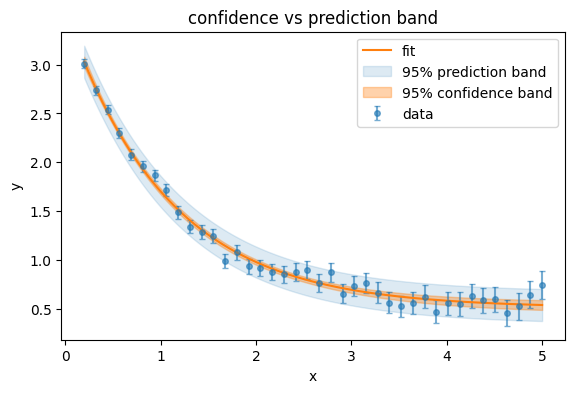

In [4]:
xx = np.linspace(0.2, 5.0, 200)
yhat, c_lo, c_hi = res.confidence_band(xx, kind='confidence')
_,    p_lo, p_hi = res.confidence_band(xx, kind='prediction')   # reuses fitted sigma(x)

plt.figure(figsize=(6.5, 4))
plt.errorbar(x, y, yerr=sigma, fmt='o', ms=4, capsize=2, alpha=0.6, label='data')
plt.plot(xx, yhat, 'C1', label='fit')
plt.fill_between(xx, p_lo, p_hi, color='C0', alpha=0.15, label='95% prediction band')
plt.fill_between(xx, c_lo, c_hi, color='C1', alpha=0.35, label='95% confidence band')
plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.title('confidence vs prediction band');

# coverage at the data points
_, clo, chi = res.confidence_band(x, kind='confidence')
_, plo, phi = res.confidence_band(x, kind='prediction')
print('data inside 95%% confidence band: %.0f%%' % (100 * np.mean((y >= clo) & (y <= chi))))
print('data inside 95%% prediction band: %.0f%%' % (100 * np.mean((y >= plo) & (y <= phi))))

## Covariance, errors, and correlation

For a least-squares fit the covariance is $s^2 (J_w^\top J_w)^{-1}$ with
$s^2 = \mathrm{SSE}/(m-n)$ — the same convention as scipy and `pycse.nlinfit`.
Here it comes straight from the inverse-Hessian block of pounce's converged KKT
factor (`cov_source == 'reduced_hessian'`).

In [5]:
print('popt :', np.round(res.popt, 4))
print('perr :', np.round(res.perr, 4))
print('95% CIs:')
for nm, (lo_, hi_) in zip(res.param_names, res.ci):
    print(f'  {nm}: [{lo_:+.4f}, {hi_:+.4f}]')
print('\ncorrelation matrix:')
print(np.round(res.correlation, 3))

popt : [3.0358 0.9337 0.5107]
perr : [0.0382 0.0324 0.0285]
95% CIs:
  a: [+2.9584, +3.1132]
  b: [+0.8681, +0.9993]
  c: [+0.4531, +0.5684]

correlation matrix:
[[ 1.     0.258 -0.225]
 [ 0.258  1.     0.822]
 [-0.225  0.822  1.   ]]


### Parity with scipy

On an ordinary least-squares fit, `pounce.curve_fit` reproduces
`scipy.optimize.curve_fit`'s `popt` and `pcov` to numerical tolerance.

In [6]:
from scipy.optimize import curve_fit as scipy_curve_fit
sp_popt, sp_pcov = scipy_curve_fit(model_np, x, y, p0=[1, 1, 0], sigma=sigma)
print('max |popt - scipy|:', np.abs(res.popt - sp_popt).max())
print('max |pcov - scipy|:', np.abs(res.pcov - sp_pcov).max())

max |popt - scipy|: 1.734340474568441e-07
max |pcov - scipy|: 1.040464369300503e-08


## Robust losses shrug off outliers

Only **smooth (C²)** losses are supported (the solver is interior-point), so
instead of a non-smooth L1/MAE you reach for a robust loss: `huber`, `cauchy`,
or `soft_l1`. The robust covariance uses the sandwich estimator
(`cov_source == 'sandwich'`).

truth        : [3.0, 0.9, 0.5]
sse   popt   : [3.231 1.02  0.585]
huber popt   : [3.065 0.968 0.529]  (cov: sandwich)


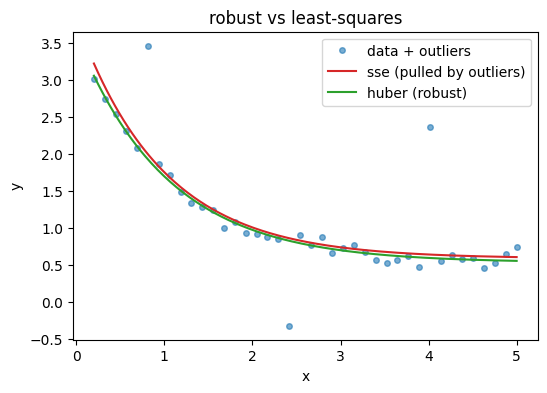

In [7]:
yo = y.copy()
yo[[5, 18, 31]] += np.array([1.5, -1.2, 1.8])      # three bad points

fit_sse = pounce.curve_fit(model, x, yo, p0=[1, 1, 0])
fit_hub = pounce.curve_fit(model, x, yo, p0=[1, 1, 0], loss='huber', f_scale=0.1)
print('truth        :', [a_true, b_true, c_true])
print('sse   popt   :', np.round(fit_sse.popt, 3))
print('huber popt   :', np.round(fit_hub.popt, 3), ' (cov:', fit_hub.cov_source + ')')

xx = np.linspace(0.2, 5.0, 200)
plt.figure(figsize=(6, 4))
plt.plot(x, yo, 'o', ms=4, alpha=0.6, label='data + outliers')
plt.plot(xx, fit_sse.predict(xx), 'C3', label='sse (pulled by outliers)')
plt.plot(xx, fit_hub.predict(xx), 'C2', label='huber (robust)')
plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.title('robust vs least-squares');

## Parameter constraints

Box bounds express **positivity / negativity / ranges**; `constraints=` (the
scipy-style dict format) expresses **relations between parameters**. When a
bound is active at the optimum the covariance is projected onto the free set and
the parameter is flagged in `res.active_mask`.

In [8]:
# force the offset c into [1.0, 2.0] even though the data prefers ~0.5
con = pounce.curve_fit(model, x, y, p0=[3, 1, 1.2], sigma=sigma,
                       bounds=[(0, np.inf), (None, None), (1.0, 2.0)])
print('constrained popt :', np.round(con.popt, 3))
print('active_mask      :', con.active_mask.tolist())
print('cov_source       :', con.cov_source)

# a relation between parameters: require a + c <= 3
rel = pounce.curve_fit(model, x, y, p0=[1.0, 1.0, 0.5], sigma=sigma,
                       constraints=[{'type': 'ineq', 'fun': lambda p: 3.0 - (p[0] + p[2])}])
print('\nrelation a+c<=3  :', np.round(rel.popt, 3), ' a+c =', round(float(rel.popt[0]+rel.popt[2]), 4))

constrained popt : [2.871 1.508 1.   ]
active_mask      : [False, False, True]
cov_source       : reduced_hessian(projected)



relation a+c<=3  : [2.717 0.617 0.283]  a+c = 3.0


## Data sensitivity: $\partial\text{params}/\partial\text{data}$

Pass `sensitivity=True` and `res.dpopt_ddata[j, i]` tells you how fitted
parameter $j$ moves when data point $y_i$ is perturbed —
$\partial p^*/\partial y_i = 2 w_i^2 H_S^{-1} g_i$, computed as one batched
back-solve against the converged factor. scipy's `curve_fit` cannot do this.

Below, the decay-rate parameter $b$ is most sensitive to the **early** points
(small $x$), where the exponential is changing fastest.

dpopt_ddata shape: (3, 40) (n_params x n_data)
most influential point for b: x = 0.20


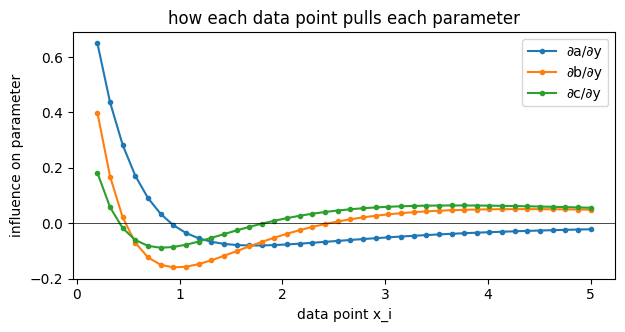

In [9]:
res = pounce.curve_fit(model, x, y, p0=[1, 1, 0], sigma=sigma, sensitivity=True)
print('dpopt_ddata shape:', res.dpopt_ddata.shape, '(n_params x n_data)')

fig, ax = plt.subplots(figsize=(7, 3.2))
for j, nm in enumerate(res.param_names):
    ax.plot(x, res.dpopt_ddata[j], 'o-', ms=3, label=f'∂{nm}/∂y')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('data point x_i'); ax.set_ylabel('influence on parameter')
ax.legend(); ax.set_title('how each data point pulls each parameter');

i = int(np.abs(res.dpopt_ddata[1]).argmax())
print(f'most influential point for b: x = {x[i]:.2f}')

## Recap

`pounce.curve_fit` gives you a scipy-compatible fit **plus** confidence
intervals, robust losses, parameter constraints, and data sensitivity — all
from one constrained solver that reuses its factorization. See the
[Curve Fitting](https://github.com/jkitchin/pounce/blob/main/docs/src/curve-fitting.md)
docs and `examples/curve_fit_demo.py` for more.